# Groupe D - Projet 1 
**Membres du Groupe :**

*   ABEGUEDIA Rosane Yvanne Boyama
*   BARRY Mamoudou
*   DAMIENS Elodie
*   GUILLEMINOT Paul
*   TOUAMI Zakaria

# Prédiction du succès d'une campagne marketing bancaire

Les banques utilisent régulièrement des campagnes téléphoniques pour proposer des produits financiers à leurs clients. Cependant, ces campagnes peuvent être coûteuses et inefficaces si les clients ciblés ne sont pas susceptibles d’accepter l’offre.

L’objectif de ce projet est d’analyser les données d’une campagne marketing bancaire afin de :

- comprendre quels profils de clients répondent positivement ;
- identifier les facteurs influençant la souscription à un produit d’épargne ;
- construire un modèle permettant de prédire quels clients sont les plus susceptibles d’accepter l’offre.

Nous utiliserons le **Bank Marketing Dataset**, qui contient des informations sur des clients contactés lors de campagnes téléphoniques.

Le projet se déroule en plusieurs étapes :

1. Compréhension et exploration des données (EDA)
    - Chargement des données
    - Description du dataset
    - Qualité des données
    - Analyse univariée

2. Création de nouvelles variables pertinentes

3. Analyse des relations entre variables et souscription

4. Construction d’un modèle de classification

5. Évaluation et interprétation des résultats

Import des librairies :

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Compréhension et exploration des données (EDA)
## Chargement des données :

In [43]:
data = pd.read_csv("bank-full.csv", sep=";")

data.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


## Description du dataset

Chaque ligne correspond à un client contacté lors d'une campagne marketing.

La variable cible du dataset est **y**, qui indique si le client a souscrit au produit d’épargne proposé.

Valeurs possibles :
- yes : le client a souscrit
- no : le client n’a pas souscrit

In [44]:
data.shape

(45211, 17)

Le dataset contient **45 211 observations** et **17 variables**.

In [45]:
data.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')

**Description des variables :**

| Variable | Description |
|------|------|
| age | âge du client |
| job | profession du client |
| marital | statut marital |
| education | niveau d’éducation |
| default | crédit en défaut |
| balance | solde bancaire |
| housing | prêt immobilier |
| loan | prêt personnel |
| contact | type de contact |
| day | jour du contact |
| month | mois du contact |
| duration | durée de l’appel |
| campaign | nombre de contacts pendant la campagne |
| pdays | jours depuis le dernier contact |
| previous | nombre de contacts précédents |
| poutcome | résultat de la campagne précédente |
| y | variable cible (souscription au produit) |

## Qualité des données
Vérification des données manquantes

In [46]:
data.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

Aucune valeur manquante n’est observée dans le dataset. Les données sont donc complètes et directement exploitables.

In [47]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


Le dataset contient :

- des variables numériques (âge, solde bancaire, durée d'appel…)
- des variables catégorielles (profession, statut marital, type de contact…)

## Analyse univariée
**Distribution de l'âge**

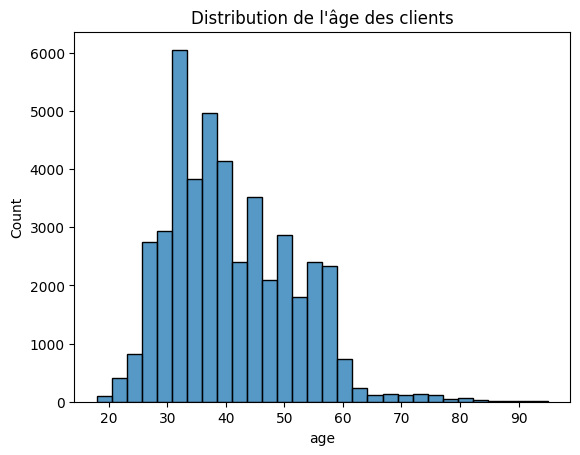

In [48]:
sns.histplot(data["age"], bins=30)
plt.title("Distribution de l'âge des clients")
plt.show()

La majorité des clients se situe entre 30 et 50 ans. Les clients très jeunes ou très âgés sont moins représentés.

**Distribution du solde bancaire**

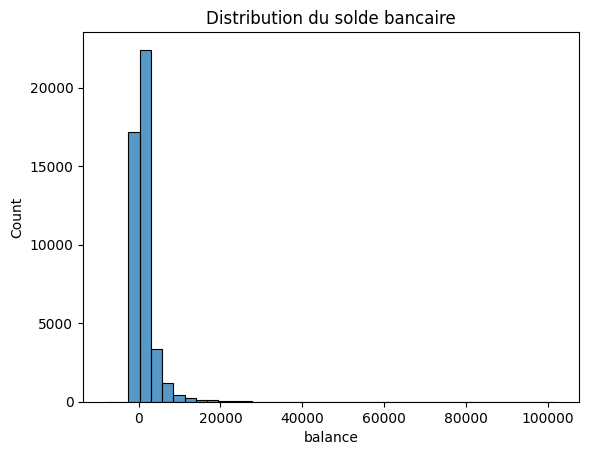

In [49]:
sns.histplot(data["balance"], bins=40)
plt.title("Distribution du solde bancaire")
plt.show()

La distribution du solde bancaire est très asymétrique. La plupart des clients possèdent un solde relativement faible, tandis qu’un petit nombre possède des soldes très élevés.

**Répartition de la variable cible**

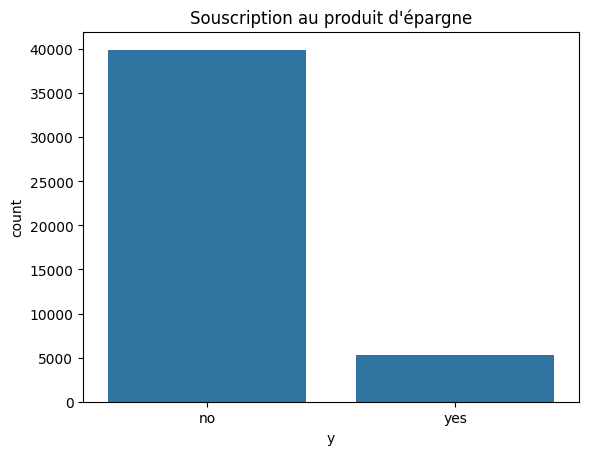

In [50]:
sns.countplot(x="y", data=data)
plt.title("Souscription au produit d'épargne")
plt.show()

# 2. Création de nouvelles variables pertinantes
Afin d’enrichir l’analyse, certaines variables dérivées ont été créées à partir des variables existantes.

## Groupe d’âge

In [51]:
data["age_group"] = pd.cut(
    data["age"],
    bins=[18,30,40,50,60,100],
    labels=["18-30","30-40","40-50","50-60","60+"]
)

## Client déjà contacté
Afin de mieux analyser l'effet de l'historique de contact sur la décision du client,
la variable *previous* a été transformée en trois catégories :

- clients jamais contactés
- clients peu contactés (1 à 4 fois)
- clients souvent contactés (5 fois ou plus)

Cette transformation permet d’observer si une sollicitation répétée influence la probabilité de souscription.

In [52]:
data["previous_contact_group"] = pd.cut(
    data["previous"],
    bins=[-1, 0, 4, 100],
    labels=[
        "Never contacted",
        "Few contacts (1-4)",
        "Many contacts (5+)"
    ]
)

## Client endetté

In [53]:
data["has_debt"] = ((data["housing"]=="yes") | (data["loan"]=="yes")).astype(int)

# 3. Analyse des relations entre variables et souscription
## Analyse bivariée

**Choix des variables pour l'analyse bivariée**

L’objectif de l’analyse bivariée est d’identifier les variables qui peuvent influencer la probabilité qu’un client souscrive au produit d’épargne proposé lors de la campagne marketing. 
Les variables analysées sont les suivantes :

**Age**
L’âge peut influencer le comportement financier des individus. Par exemple, les clients plus âgés peuvent être plus enclins à investir dans des produits d’épargne.

**Balance**
Le solde bancaire reflète la situation financière du client. Les clients disposant de ressources financières plus importantes peuvent avoir une plus grande capacité d’épargne.

**Job**
La profession peut être liée au niveau de revenu ou à la stabilité financière, ce qui peut influencer la probabilité de souscription.

**Campaign**
Cette variable indique le nombre de contacts effectués durant la campagne. Elle permet d’analyser si un nombre élevé d’appels augmente ou réduit la probabilité d’acceptation.

**Poutcome**
Le résultat de la campagne précédente est une information importante. Un client ayant déjà répondu positivement à une campagne passée peut être plus susceptible d’accepter une nouvelle offre.

Ces variables couvrent donc trois dimensions importantes : le profil du client, sa situation financière et l’historique des interactions marketing avec la banque.

Certaines variables n’ont pas été analysées en détail dans cette section car elles apportent moins d’informations directes sur la décision de souscription ou sont plus difficiles à interpréter dans une analyse exploratoire simple (par exemple : day ou contact).

Elles pourront néanmoins être utilisées dans la phase de modélisation afin d’évaluer leur contribution prédictive.

**Age vs souscription**

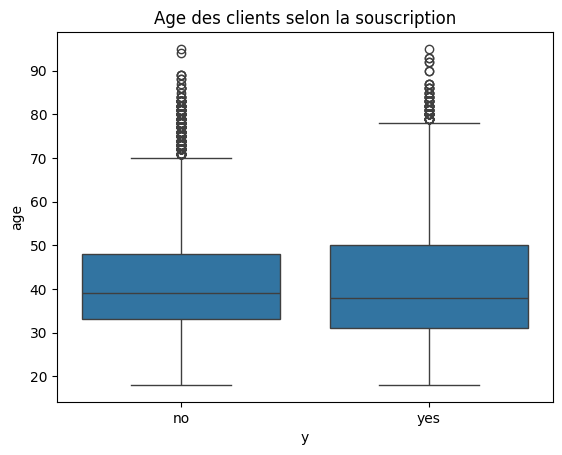

In [54]:
sns.boxplot(x="y", y="age", data=data)
plt.title("Age des clients selon la souscription")
plt.show()

Les clients ayant souscrit semblent légèrement plus âgés en moyenne. L’âge pourrait donc influencer la décision d’épargne.

**Solde bancaire vs souscription**

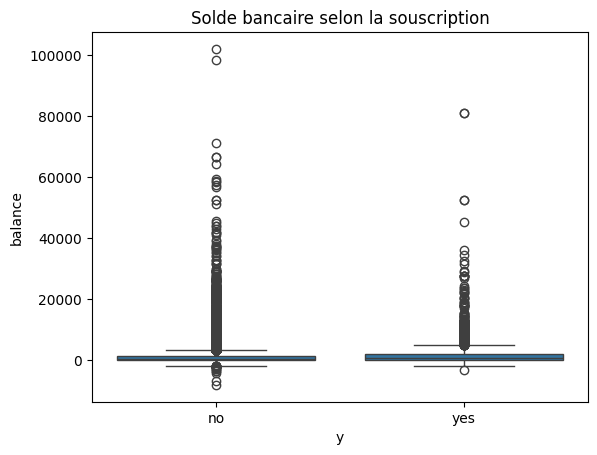

In [55]:
sns.boxplot(x="y", y="balance", data=data)
plt.title("Solde bancaire selon la souscription")
plt.show()

Les clients possédant un solde bancaire plus élevé semblent davantage enclins à souscrire à un produit d’épargne.

**Profession vs souscription**

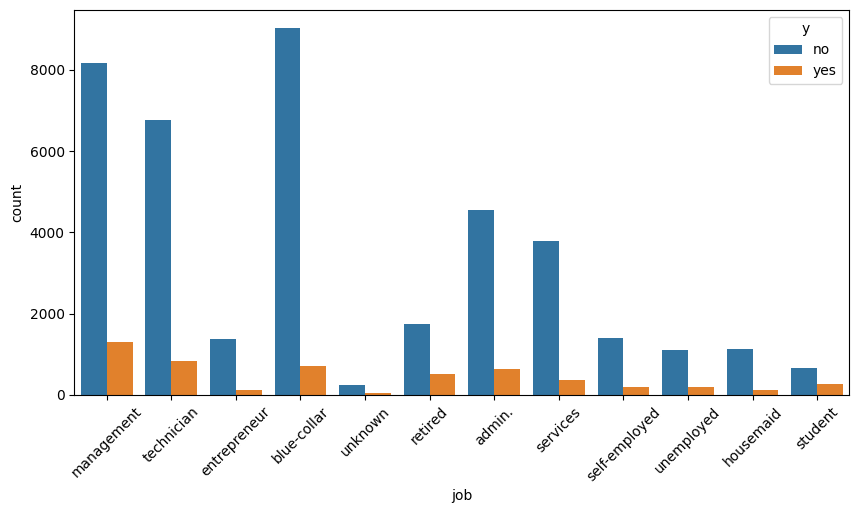

In [56]:
plt.figure(figsize=(10,5))
sns.countplot(x="job", hue="y", data=data)
plt.xticks(rotation=45)
plt.show()

Certaines professions présentent un taux de souscription plus élevé. Les retraités et les cadres semblent par exemple plus susceptibles d’accepter l’offre.

**Nombre d'appels vs souscription**

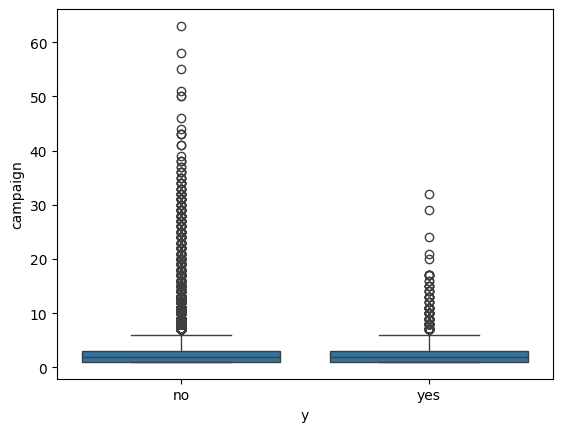

In [57]:
sns.boxplot(x="y", y="campaign", data=data)
plt.show()

Les clients contactés un grand nombre de fois semblent moins susceptibles de souscrire. Une pression marketing excessive peut donc réduire l’efficacité des campagnes.

**Résultat des campagnes précédentes**

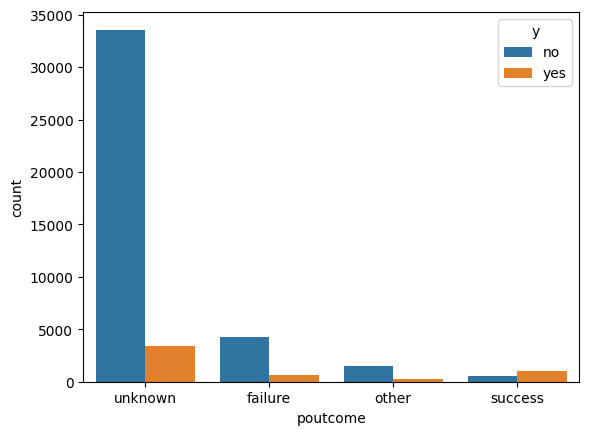

In [58]:
sns.countplot(x="poutcome", hue="y", data=data)
plt.show()

Une grande partie des valeurs est : unknown
La cause est que beaucoup de clients n’ont jamais été contactés auparavant.
Cela correspond souvent à : pdays = -1

Les clients ayant déjà répondu positivement à une campagne précédente présentent une probabilité beaucoup plus élevée de souscrire à nouveau.

**Historique de contact vs souscription**

Comparer uniquement le nombre de clients dans chaque catégorie peut être trompeur, car les groupes n’ont pas la même taille (beaucoup de Never contacted)

Afin d’obtenir une comparaison plus pertinente, nous analysons le **taux de souscription**, c’est-à-dire la proportion de clients ayant accepté l’offre dans chaque groupe.

In [59]:
subscription_rate = (
    data.groupby("previous_contact_group")["y"]
    .value_counts(normalize=True)
    .unstack()
)

subscription_rate

C:\Users\Elodi\AppData\Local\Temp\ipykernel_3636\2880164423.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby("previous_contact_group")["y"]


y,no,yes
previous_contact_group,,
Never contacted,0.908427,0.091573
Few contacts (1-4),0.776656,0.223344
Many contacts (5+),0.736531,0.263469


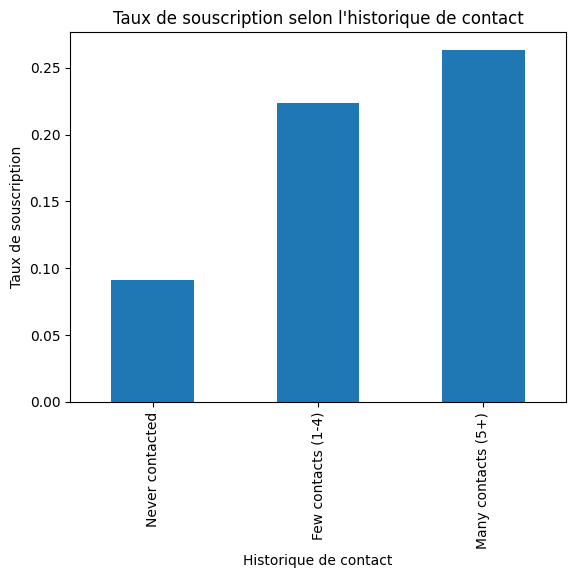

In [60]:
subscription_rate["yes"].plot(kind="bar")

plt.title("Taux de souscription selon l'historique de contact")
plt.xlabel("Historique de contact")
plt.ylabel("Taux de souscription")

plt.show()

Ce graphique montre la proportion de clients ayant souscrit au produit d’épargne dans chaque catégorie.

L’analyse des taux permet de comparer les groupes indépendamment de leur taille. Elle permet d’identifier si l’historique de contact influence la probabilité de souscription.

Une sollicitation modérée pourrait être plus efficace qu’une sollicitation trop fréquente, ce qui pourrait refléter un phénomène de "fatigue marketing" lorsque les clients sont contactés trop souvent.

# 4. Construction d’un modèle de classification
## Préparation des données
**Encodage des variables catégorielles**

In [61]:
data_encoded = pd.get_dummies(data, drop_first=True)

# Suppression de la variable duration

La variable **duration** correspond à la durée de l’appel téléphonique.

Elle est fortement corrélée à la souscription mais elle n’est connue qu’après l’appel. Son utilisation dans un modèle prédictif introduirait une fuite d’information (data leakage).

Elle est donc retirée des variables explicatives.

In [62]:
X = data_encoded.drop(["y_yes","duration"], axis=1)
y = data_encoded["y_yes"]